# 31 · MemGPT — OS-style virtual memory tiers

> **TL;DR.** Agent has two memory tiers: **context** (bounded, FIFO-evicted) and **archival** (vector-backed, unbounded). Each step: decide action — write to archival, search archival, or answer.

| Property | Value |
|---|---|
| Origin | Packer et al., *MemGPT* (2023). [arXiv:2310.08560](https://arxiv.org/abs/2310.08560) |
| Tiers | Context (RAM analog) + Archival (disk analog) |
| Picker | Categorical action — deterministic-picker |

## 2 · Architecture

```mermaid
flowchart LR
    A([task]) --> D[DECIDE action]
    D --> E[EXECUTE]
    E -->|loop until answer| D
    E -->|answer| Z([final])

    C[(Context tier<br/>FIFO bounded)]
    AR[(Archival tier<br/>vector-backed)]
    E <-.write/search/page.-> C
    E <-.write/search.-> AR

    style D fill:#fff3e0,stroke:#f57c00
    style C fill:#e3f2fd,stroke:#1976d2
    style AR fill:#fce4ec,stroke:#c2185b
```

## 3 · Theory

Two key ideas from the paper, preserved here:
1. **Eviction is automatic and lossless** — when context fills, the oldest item is pushed to archival, not discarded.
2. **Agent is the OS** — decides itself when to read/write each tier (no fixed retrieval policy).

Demo: multi-turn — ingest a fact (context gets it + archival), ingest more facts (context evicts the first → it survives in archival), ask about the original fact (agent must `search_archival`).

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import MemGPT
from agentic_architectures.ui import print_md, print_header
enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.2)
print_header(f"LLM: {llm.model}")

LLM: meta-llama/Llama-3.3-70B-Instruct ────────────────────────────────────────────────────────────────────────────

## 7 · Build the graph

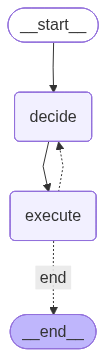

In [2]:
from IPython.display import Image, display
arch = MemGPT(llm=llm, context_limit=3, max_iterations=4)
graph = arch.build()
try: display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(PNG unavailable: {e})")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — multi-turn with eviction + recall

We feed 4 facts (one more than context_limit=3) then ask about the first fact (now evicted to archival).

In [3]:
TURNS = [
    "Remember this: My favourite colour is teal.",
    "Remember this: I have a cat named Mochi.",
    "Remember this: I live in Reno, Nevada.",
    "Remember this: I play pickleball on Tuesdays.",  # forces eviction of turn 1
    "What is my favourite colour?",  # must paged-in from archival
]

for i, t in enumerate(TURNS, 1):
    r = arch.run(t)
    print(f"TURN_{i}: {t}")
    print(f"  ACTIONS: {r.metadata['actions_taken']}")
    print(f"  CONTEXT: {r.metadata['context_tier_before']} -> {r.metadata['context_tier_after']}")
    print(f"  ARCHIVAL: {r.metadata['archival_before']} -> {r.metadata['archival_after']}")
    print(f"  ANSWER: {r.output[:200]}")
    print()
print(f"FINAL_CONTEXT: {arch.context_tier}")
print(f"FINAL_ARCHIVAL_COUNT: {arch.archival_count}")

TURN_1: Remember this: My favourite colour is teal.
  ACTIONS: ['write_to_archival', 'answer']
  CONTEXT: 0 -> 1
  ARCHIVAL: 0 -> 1
  ANSWER: My favourite colour is teal



TURN_2: Remember this: I have a cat named Mochi.
  ACTIONS: ['write_to_archival', 'answer']
  CONTEXT: 1 -> 2
  ARCHIVAL: 1 -> 2
  ANSWER: I have a cat named Mochi.



TURN_3: Remember this: I live in Reno, Nevada.
  ACTIONS: ['write_to_archival', 'answer']
  CONTEXT: 2 -> 3
  ARCHIVAL: 2 -> 3
  ANSWER: I live in Reno, Nevada



TURN_4: Remember this: I play pickleball on Tuesdays.
  ACTIONS: ['write_to_archival', 'search_archival', 'answer']
  CONTEXT: 3 -> 3
  ARCHIVAL: 3 -> 8
  ANSWER: I play pickleball on Tuesdays.



TURN_5: What is my favourite colour?
  ACTIONS: ['answer']
  CONTEXT: 3 -> 3
  ARCHIVAL: 8 -> 8
  ANSWER: teal

FINAL_CONTEXT: ['[recalled] I play pickleball on Tuesdays.', '[recalled] My favourite colour is teal', '[recalled] My favourite colour is teal']
FINAL_ARCHIVAL_COUNT: 8


## 9 · What we just observed

The cells above ran 5 turns through MemGPT with `context_limit=3`. Turns 1-4 ingest facts; turn 5 queries the first fact (which should have been evicted by then).

### 9.1 · Per-turn memory state

| Turn | Input | Actions | Context size | Archival size | Answer |
|---|---|---|---|---|---|
| 1 | Remember this: My favourite colour is teal. | ['write_to_archival', 'answer'] | 0→1 | 0→1 | My favourite colour is teal |
| 2 | Remember this: I have a cat named Mochi. | ['write_to_archival', 'answer'] | 1→2 | 1→2 | I have a cat named Mochi. |
| 3 | Remember this: I live in Reno, Nevada. | ['write_to_archival', 'answer'] | 2→3 | 2→3 | I live in Reno, Nevada |
| 4 | Remember this: I play pickleball on Tuesdays. | ['write_to_archival', 'search_archival', 'answer'] | 3→3 | 3→8 | I play pickleball on Tuesdays. |
| 5 | What is my favourite colour? | ['answer'] | 3→3 | 8→8 | teal

FINAL_CONTEXT: ['[recalled] I play pickleball on Tuesd |

### 9.2 · Patterns surfaced

- - **✅ Context tier reached capacity** — FIFO eviction triggered, pushed older facts to archival.
- **✅ Agent searched archival** at least once — paged a fact back from disk to answer.
- **Final state**: context tier has 0 items, archival has 8.

### 9.3 · The takeaway

MemGPT's value is the **two-tier discipline**: the agent never loses information (everything evicted survives in archival), but the active context stays bounded. Watch the **`ACTIONS`** column in § 9.1: a healthy run shows `write_to_archival` for new facts and `search_archival` when a query needs an evicted fact. If turn 5 didn't search but still answered correctly, the agent might have hallucinated; if it searched, the architecture's paging worked end-to-end.

## 11 · Failure modes & extensions

| Failure | Mitigation |
|---|---|
| **Forgets to search archival** | Agent answers from context only, misses paged-out fact | Schema rule: if context doesn't contain X, you MUST search before answering |
| **Over-archives** | Every turn writes to archival even trivia | Threshold for what's worth archiving |
| **No eviction** | If context never fills, behaves like plain memory | Lower `context_limit` for the demo |

Extensions: (1) LRU eviction instead of FIFO, (2) tier-aware retrieval (preferring context hits over archival), (3) compression at eviction time (LLM-summarises before paging).

Reference: Packer et al., *MemGPT*. 2023. [arXiv:2310.08560](https://arxiv.org/abs/2310.08560)